<h1 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);text-align:center;font-weight:bold;padding:18px 12px;border-radius:10px;margin-bottom:7px;">
Week 9 — Day 3: Interactive Streamlit Dashboard
</h1>
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;">
Building a User Interface for the IMDb Sentiment Analysis Model
</h3>
<div style="border-left:6px solid #FB7185;background-color:#FFF1F2;padding:12px 16px;margin:16px 0;border-radius:6px;color:#7F1D1D;">
<b>Week 9 — Model Deployment • Sprint 4 • Day 3</b><br>
Day 1 saved the model. Day 2 served it with FastAPI. Day 3 gives it a user interface with Streamlit.
</div>

<a id="section14"></a>
<a id="section13"></a>
<a id="section12"></a>
<a id="section11"></a>
<a id="section10"></a>
<a id="section9"></a>
<a id="section8"></a>
<a id="section7"></a>
<a id="section6"></a>
<a id="section5"></a>
<a id="section4"></a>
<a id="section3"></a>
<a id="section2"></a>
<a id="section1"></a>
<a id="section0"></a>
<a id="toc"></a>
<h2 style="color:#92400E;background-color:#FBBF24;font-weight:bold;margin-top:30px;padding:9px 14px;border-radius:7px;">
Table of Contents
</h2>

<div style="border:1px solid #CBD5E1;padding:16px 25px;border-radius:8px;background-color:#FFFFFF;color:#111827;">
<ul style="font-weight:bold;line-height:1.95;color:#1F2937;">
<li><a href="#section0">0. Setup — Files & Environment</a></li>
<li><a href="#section1">1. Day 3 Learning Map</a></li>
<li><a href="#section2">2. Why Streamlit</a></li>
<li><a href="#section3">3. Common Streamlit Widgets</a></li>
<li><a href="#section4">4. Load the Saved Model Pipeline</a></li>
<li><a href="#section5">5. Prediction Logic</a></li>
<li><a href="#section6">6. Confidence Visualization</a></li>
<li><a href="#section7">7. Final app.py</a></li>
<li><a href="#section8">8. Run Streamlit Locally</a></li>
<li><a href="#section9">9. Test Positive and Negative Reviews</a></li>
<li><a href="#section10">10. Design a Usable Demo</a></li>
<li><a href="#section13">11. What I Learned Today</a></li>
</ul>
</div>

<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">0. Setup — Files & Environment</h2>

<div style="background:#F8F8F8;color:#111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;line-height:1.7;">
<pre style="background:#CCFBF1;color:#111827;padding:12px;border-radius:8px;">Week 9/
└── Day 3/
    ├── Day3.ipynb
    ├── app.py
    ├── preprocessing.py
    ├── sentiment_model.joblib
    └── tfidf_vectorizer.joblib</pre>
<p><b>Important:</b> We reuse the saved model pipeline. We do not retrain the model.</p>
</div>

In [15]:
from pathlib import Path

DAY3_DIR = Path.cwd().resolve()
print("Current directory:", DAY3_DIR)

for name in ["preprocessing.py", "sentiment_model.joblib", "tfidf_vectorizer.joblib"]:
    path = DAY3_DIR / name
    print("[OK]" if path.exists() else "[MISSING]", name)

Current directory: C:\Users\sadee\OneDrive\Desktop\The Main Folder\The Main Folder\Week 9\Day 3
[OK] preprocessing.py
[OK] sentiment_model.joblib
[OK] tfidf_vectorizer.joblib


In [16]:
import streamlit as st
print("Streamlit version:", st.__version__)

Streamlit version: 1.51.0


<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">1. Day 3 Learning Map</h2>

<div style="background:#F8F8F8;color:#111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;">
<pre style="background:#CCFBF1;color:#111827;padding:12px;border-radius:8px;">Day 1
Save model + preprocessing
        ↓
Day 2
Serve model with FastAPI
        ↓
Day 3
Build Streamlit UI
        ↓
User enters review
        ↓
Prediction + confidence</pre>
</div>

<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">2. Why Streamlit</h2>

<div style="background:#F8F8F8;color:#111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;line-height:1.7;">
<table style="width:100%;border-collapse:collapse;">
<tr style="background:#0F766E;color:white;"><th style="padding:9px;border:1px solid #CBD5E1;">Tool</th><th style="padding:9px;border:1px solid #CBD5E1;">Audience</th><th style="padding:9px;border:1px solid #CBD5E1;">Purpose</th></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;"><b>FastAPI</b></td><td style="padding:9px;border:1px solid #CBD5E1;">Programs</td><td style="padding:9px;border:1px solid #CBD5E1;">REST API and JSON</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;"><b>Streamlit</b></td><td style="padding:9px;border:1px solid #CBD5E1;">People</td><td style="padding:9px;border:1px solid #CBD5E1;">Interactive web UI</td></tr>
</table>
</div>

<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">3. Common Streamlit Widgets</h2>

<div style="background:#F8F8F8;color:#111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;line-height:1.7;">
<table style="width:100%;border-collapse:collapse;">
<tr style="background:#0F766E;color:white;"><th style="padding:9px;border:1px solid #CBD5E1;">Widget</th><th style="padding:9px;border:1px solid #CBD5E1;">Purpose</th></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;"><code>st.number_input / st.slider</code></td><td style="padding:9px;border:1px solid #CBD5E1;">Numeric input</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;"><code>st.selectbox / st.radio</code></td><td style="padding:9px;border:1px solid #CBD5E1;">Categories</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;"><code>st.text_input / st.text_area</code></td><td style="padding:9px;border:1px solid #CBD5E1;">Text input</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;"><code>st.file_uploader</code></td><td style="padding:9px;border:1px solid #CBD5E1;">Upload files</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;"><code>st.write / st.success / st.progress</code></td><td style="padding:9px;border:1px solid #CBD5E1;">Display results</td></tr>
</table>
<p>For sentiment analysis, <code>st.text_area</code> is appropriate because movie reviews can be long.</p>
</div>

<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">4. Load the Saved Model Pipeline</h2>

In [17]:
import joblib
from preprocessing import preprocess_to_string

vectorizer = joblib.load("tfidf_vectorizer.joblib")
model = joblib.load("sentiment_model.joblib")

print(type(vectorizer))
print(type(model))

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [18]:
sample_review = "This movie was fantastic, emotional, and beautifully made."

clean_review = preprocess_to_string(sample_review)
X = vectorizer.transform([clean_review])
prediction = model.predict(X)[0]

print("Clean review:", clean_review)
print("Prediction:", prediction)

Clean review: movie fantastic emotional beautifully make
Prediction: positive


<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">5. Prediction Logic</h2>

In [19]:
def predict_sentiment(review_text):
    clean_text = preprocess_to_string(review_text)
    X = vectorizer.transform([clean_text])
    prediction = model.predict(X)[0]
    return clean_text, prediction

cleaned, pred = predict_sentiment(
    "This movie was boring, terrible, and disappointing."
)

print("Cleaned:", cleaned)
print("Prediction:", pred)

Cleaned: movie bore terrible disappointing
Prediction: negative


<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">6. Confidence Visualization</h2>

<div style="background:#F8F8F8;color:#111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;line-height:1.7;">
<p>A supporting visualization makes the result easier to understand.</p>
<pre style="background:#CCFBF1;color:#111827;padding:12px;border-radius:8px;">Prediction: positive
Confidence: 86.54%

[=================---]</pre>
<p><b>Important:</b> this confidence is the predicted class probability from the classifier.</p>
</div>

In [20]:
def predict_with_confidence(review_text):
    clean_text = preprocess_to_string(review_text)
    X = vectorizer.transform([clean_text])

    prediction = model.predict(X)[0]
    probabilities = model.predict_proba(X)[0]

    class_index = list(model.classes_).index(prediction)
    confidence = float(probabilities[class_index])

    return clean_text, prediction, confidence

cleaned, pred, confidence = predict_with_confidence(
    "This movie was fantastic, emotional, and beautifully made."
)

print("Prediction:", pred)
print(f"Confidence: {confidence * 100:.2f}%")

Prediction: positive
Confidence: 86.54%


<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">7. Final app.py</h2>

<div style="background:#F8F8F8;color:#111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;line-height:1.7;">
<p>The final Streamlit application uses:</p>
<pre style="background:#CCFBF1;color:#111827;padding:12px;border-radius:8px;">st.title()
st.write()
st.text_area()
st.button()
st.success()
st.progress()</pre>
<p>The application flow is:</p>
<pre style="background:#CCFBF1;color:#111827;padding:12px;border-radius:8px;">Review
  ↓
preprocess_to_string()
  ↓
vectorizer.transform()
  ↓
model.predict()
  ↓
model.predict_proba()
  ↓
Prediction + Confidence</pre>
</div>

In [21]:
# Core app.py logic for reference

app_example = '''
from pathlib import Path
import joblib
import streamlit as st
from preprocessing import preprocess_to_string

BASE_DIR = Path(__file__).resolve().parent

vectorizer = joblib.load(BASE_DIR / "tfidf_vectorizer.joblib")
model = joblib.load(BASE_DIR / "sentiment_model.joblib")

st.title("IMDb Sentiment Analysis")

st.write(
    "Enter a movie review below and the model will predict "
    "whether the sentiment is positive or negative."
)

review = st.text_area("Enter your movie review:")

if st.button("Predict"):
    if review.strip() == "":
        st.warning("Please enter a movie review.")
    else:
        clean_review = preprocess_to_string(review)
        X = vectorizer.transform([clean_review])

        prediction = model.predict(X)[0]
        probabilities = model.predict_proba(X)[0]

        class_index = list(model.classes_).index(prediction)
        confidence = float(probabilities[class_index])

        st.success(f"Prediction: {prediction}")
        st.write(f"Confidence: {confidence * 100:.2f}%")
        st.progress(confidence)
'''

print(app_example)


from pathlib import Path
import joblib
import streamlit as st
from preprocessing import preprocess_to_string

BASE_DIR = Path(__file__).resolve().parent

vectorizer = joblib.load(BASE_DIR / "tfidf_vectorizer.joblib")
model = joblib.load(BASE_DIR / "sentiment_model.joblib")

st.title("IMDb Sentiment Analysis")

st.write(
    "Enter a movie review below and the model will predict "
    "whether the sentiment is positive or negative."
)

review = st.text_area("Enter your movie review:")

if st.button("Predict"):
    if review.strip() == "":
        st.warning("Please enter a movie review.")
    else:
        clean_review = preprocess_to_string(review)
        X = vectorizer.transform([clean_review])

        prediction = model.predict(X)[0]
        probabilities = model.predict_proba(X)[0]

        class_index = list(model.classes_).index(prediction)
        confidence = float(probabilities[class_index])

        st.success(f"Prediction: {prediction}")
        st.write(f"Confidence: {con

<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">8. Run Streamlit Locally</h2>

<div style="background:#F8F8F8;color:#111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;line-height:1.7;">
<p>Run from PowerShell inside <code>Week 9/Day 3</code>:</p>
<pre style="background:#CCFBF1;color:#111827;padding:12px;border-radius:8px;">python -m streamlit run app.py</pre>
<p>Local URL:</p>
<pre style="background:#CCFBF1;color:#111827;padding:12px;border-radius:8px;">http://localhost:8501</pre>
</div>

<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">9. Test Positive and Negative Reviews</h2>

<div style="background:#F8F8F8;color:#111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;line-height:1.7;">
<h3 style="background:#F8EEEE;color:#7F1D1D;border-left:6px solid #7F1D1D;padding:9px 12px;">Positive Test</h3>
<pre style="background:#E0F2FE;color:#111827;padding:12px;border-radius:8px;">This movie was fantastic, emotional, and beautifully made.</pre>
<h3 style="background:#F8EEEE;color:#7F1D1D;border-left:6px solid #7F1D1D;padding:9px 12px;">Negative Test</h3>
<pre style="background:#E0F2FE;color:#111827;padding:12px;border-radius:8px;">This movie was boring, terrible, disappointing, and a complete waste of time.</pre>
</div>

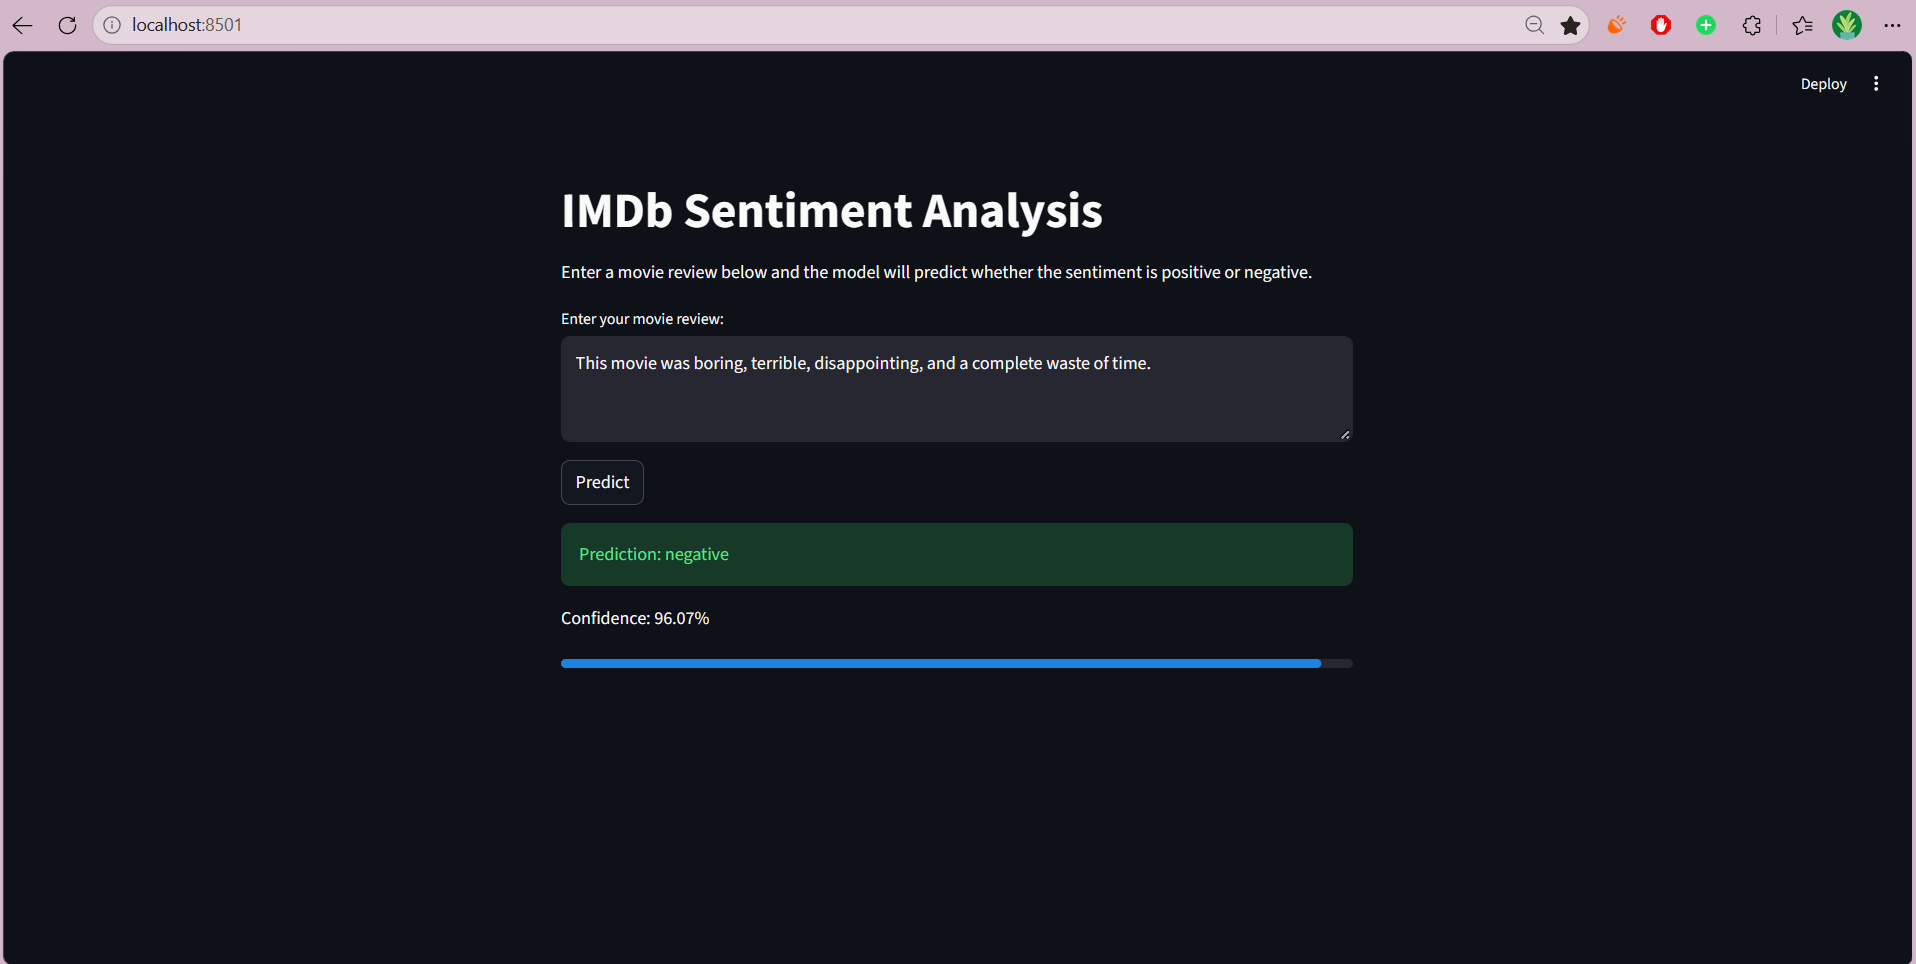

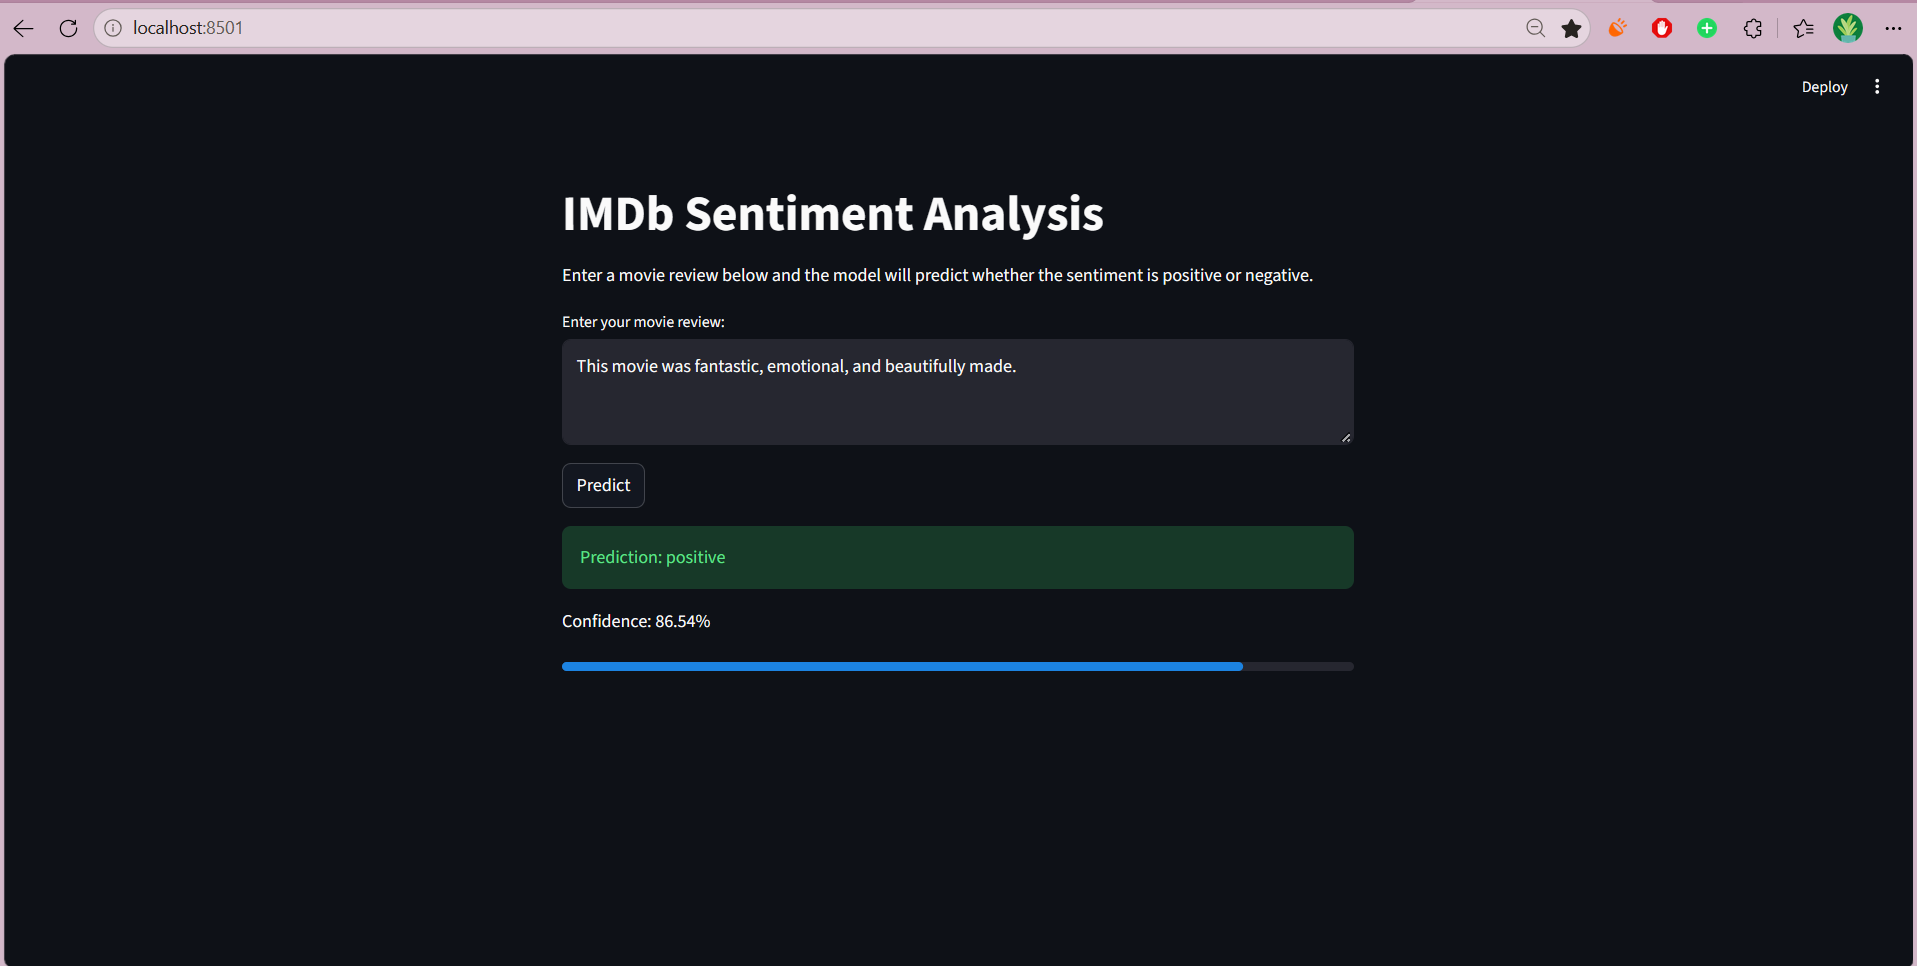

<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">10. Design a Usable Demo</h2>

<div style="background:#F8F8F8;color:#111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;line-height:1.7;">
<ul style="line-height:1.9;">
<li>Clear title and short description</li>
<li>Appropriate text input</li>
<li>Visible Predict button</li>
<li>Prominent sentiment result</li>
<li>Supporting confidence visualization</li>
<li>A first-time user can get a prediction easily</li>
</ul>
</div>

<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">11. What I Learned Today</h2>

<div style="background:#F8F8F8;color:#111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;line-height:1.7;">
<ul style="line-height:1.9;">
<li>I learned why <b>Streamlit</b> is useful for non-technical users.</li>
<li>I learned the difference between <b>FastAPI for programs</b> and <b>Streamlit for people</b>.</li>
<li>I learned how to use <code>st.title()</code>, <code>st.write()</code>, <code>st.text_area()</code>, and <code>st.button()</code>.</li>
<li>I learned how to load the saved TF-IDF vectorizer and Logistic Regression model inside a Streamlit app.</li>
<li>I learned how to reuse the same preprocessing used during training.</li>
<li>I learned to use <code>vectorizer.transform()</code> instead of fitting the vectorizer again.</li>
<li>I learned how to display the predicted sentiment clearly.</li>
<li>I learned how to use <code>predict_proba()</code> to calculate model confidence.</li>
<li>I learned how to display confidence using a Streamlit progress bar.</li>
<li>I learned how to test the app with positive and negative movie reviews.</li>
<li>I learned how to run Streamlit locally using <code>python -m streamlit run app.py</code>.</li>
</ul>
</div>